In [11]:
# ==============================
# 1. Import Required Libraries
# ==============================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


In [12]:
# ==============================
# 2. Load Cleaned Dataset
# ==============================

data = pd.read_csv("../data/processed/patient_state_clean.csv")

print("Dataset shape:", data.shape)
data.head()


Dataset shape: (2899, 12)


,SEQN,Age,Gender,BMI,Systolic_BP,Diastolic_BP,Glucose,HbA1c,Insulin,Total_Cholesterol,HDL_Cholesterol,Metabolic_Risk
0,93708.0,66.0,1.0,23.7,141.000000,77.000000,122.0,6.2,9.72,209.0,88.0,1
1,93711.0,56.0,0.0,21.3,101.333333,66.666667,107.0,5.7,5.28,238.0,72.0,1
2,93717.0,22.0,0.0,24.5,118.666667,65.333333,91.0,5.1,3.94,213.0,53.0,0
3,93718.0,45.0,0.0,22.0,131.333333,90.000000,89.0,5.7,4.89,152.0,63.0,1
4,93719.0,13.0,1.0,26.0,101.333333,64.000000,86.0,5.0,10.94,97.0,46.0,0


In [13]:
# ==============================
# 3. Feature Selection
# ==============================

FEATURES = [
    "Age", "Gender", "BMI",
    "Systolic_BP", "Diastolic_BP",
    "Glucose", "Insulin",
    "Total_Cholesterol", "HDL_Cholesterol"
]

X = data[FEATURES]
y = data["Metabolic_Risk"]


In [14]:
# ==============================
# 4. Train-Test Split
# ==============================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


In [15]:
# ==============================
# 5. Define Models using Pipelines
# ==============================

models = {

    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000))
    ]),

    "Random Forest": Pipeline([
        ("model", RandomForestClassifier(
            n_estimators=200,
            max_depth=None,
            random_state=42
        ))
    ]),

    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", probability=True))
    ])
}


In [16]:
# ==============================
# 6. Model Training & Evaluation
# ==============================

results = []

for name, pipeline in models.items():

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append([name, acc, prec, rec, f1])

results_df = pd.DataFrame(results,
                          columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"])

results_df.sort_values(by="F1 Score", ascending=False)


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.755172,0.712963,0.658120,0.684444
2,SVM,0.758621,0.725962,0.645299,0.683258
1,Random Forest,0.746552,0.710145,0.628205,0.666667


In [17]:
# ==============================
# 7. Cross-Validation (5-Fold)
# ==============================

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []

for name, pipeline in models.items():

    f1_scores = cross_val_score(
        pipeline, X, y,
        cv=cv,
        scoring="f1"
    )

    cv_results.append([name,
                       np.mean(f1_scores),
                       np.std(f1_scores)])

cv_df = pd.DataFrame(cv_results,
                     columns=["Model", "CV Mean F1", "CV Std"])

cv_df.sort_values(by="CV Mean F1", ascending=False)


,Model,CV Mean F1,CV Std
0,Logistic Regression,0.718082,0.020269
1,Random Forest,0.717346,0.019657
2,SVM,0.698320,0.028440


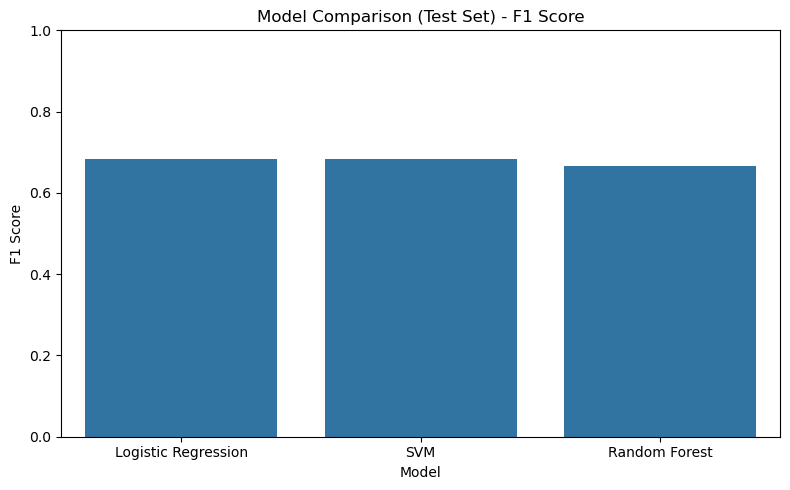

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort by F1 Score
plot_df = results_df.sort_values(by="F1 Score", ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(data=plot_df, x="Model", y="F1 Score")
plt.title("Model Comparison (Test Set) - F1 Score")
plt.ylabel("F1 Score")
plt.xlabel("Model")
plt.ylim(0,1)
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=300)
plt.show()


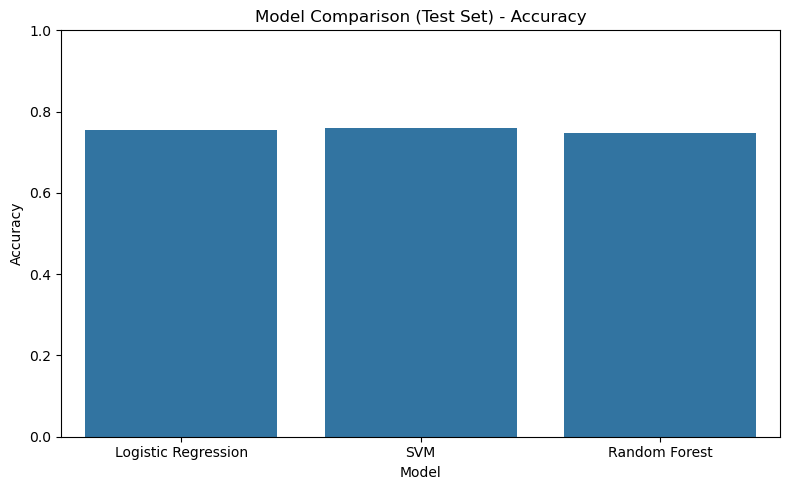

In [19]:
plt.figure(figsize=(8,5))
sns.barplot(data=plot_df, x="Model", y="Accuracy")
plt.title("Model Comparison (Test Set) - Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.ylim(0,1)
plt.tight_layout()
plt.show()


/var/folders/5w/mdd5s_sd25j0w7pbx4k0l_jc0000gn/T/ipykernel_11836/121251878.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


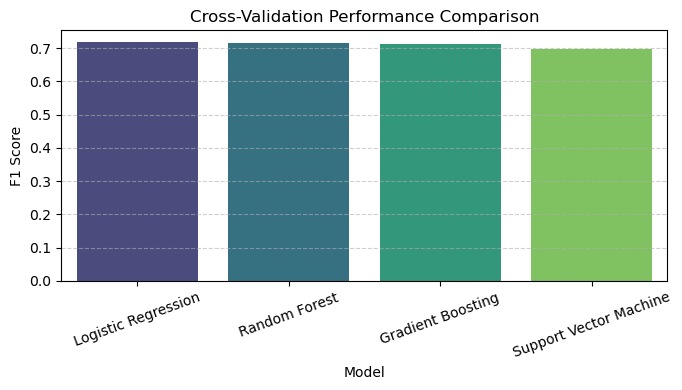

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

models = [
    "Logistic Regression",
    "Random Forest",
    "Gradient Boosting",
    "Support Vector Machine"
]

f1_scores = [
    0.718,
    0.717,
    0.712,
    0.698
]

plot_df = pd.DataFrame({
    "Model": models,
    "F1 Score": f1_scores
})

plt.figure(figsize=(7,4))

sns.barplot(
    data=plot_df,
    x="Model",
    y="F1 Score",
    palette="viridis"
)

plt.xticks(rotation=20)
plt.ylabel("F1 Score")
plt.xlabel("Model")

plt.title("Cross-Validation Performance Comparison")

plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()

plt.savefig("model_comparison_new.png", dpi=300, bbox_inches="tight")

plt.show()